[NOTEBOOK LINK](https://colab.research.google.com/drive/1JaGzBeQpczyWG7wsN5W59scXl-wOforx)

In [9]:
# tidyverse includes ggplot2 for visualisation and other useful tools
install.packages("tidyverse")
library(tidyverse)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [10]:
# Loading cleaned datasets from GitHub
BASE_URL = "https://raw.githubusercontent.com/DaNIsH-768/DBA_ASSESSMENT/refs/heads/main/cleaned_data/"

complaints <- read.csv(paste0(BASE_URL, "complaints_clean.csv"))
deliveries <- read.csv(paste0(BASE_URL, "deliveries_clean.csv"))
orders     <- read.csv(paste0(BASE_URL, "orders_clean.csv"))
customers  <- read.csv(paste0(BASE_URL, "customers_clean.csv"))
drivers    <- read.csv(paste0(BASE_URL, "drivers_clean.csv"))
vehicles   <- read.csv(paste0(BASE_URL, "vehicles_clean.csv"))
hubs       <- read.csv(paste0(BASE_URL, "hubs_clean.csv"))


In [11]:
# Merging deliveries with vehicles to get battery health alongside delivery data
merged_deliveries <- merge(deliveries, vehicles, by="vehicle_id")
head(merged_deliveries)


,vehicle_id,delivery_id,order_id,driver_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,⋯,complaint_filed,on_time_flag,failure_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,⋯,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>
1,V001,DL00325,O00582,D108,H08,2024-11-06 12:05:00,2024-11-06 11:51:52.065126,OnTime,14.87,0,⋯,0,1,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
2,V001,DL00252,O00713,D109,H05,2024-07-10 01:06:00,2024-07-10 05:10:04.532246,OnTime,11.34,0,⋯,0,1,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
3,V001,DL00592,O00526,D146,H04,2024-01-19 17:17:00,2024-01-19 20:32:43.768544,OnTime,17.21,2,⋯,0,1,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
4,V001,DL00660,O00016,D008,H02,2025-07-29 13:52:00,2025-07-29 17:01:03.042495,OnTime,16.10,2,⋯,0,1,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
5,V001,DL00126,O00547,D159,H07,2024-04-09 14:36:00,2024-04-10 19:11:28.149157,Delayed,17.68,0,⋯,0,0,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
6,V001,DL00909,O01204,D033,H02,2025-08-13 17:56:00,2025-08-13 20:26:21.358387,Delayed,10.35,2,⋯,0,0,0,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2


## Linear Regression

Testing whether battery health predicts delivery failure rate.
This directly tests Hypothesis 2.


In [12]:
# Simple linear regression - battery health vs failure flag
# failure_flag is the dependent variable (what we are trying to predict)
# battery_health_pct is the independent variable (the predictor)
lm_model <- lm(failure_flag ~ battery_health_pct, data = merged_deliveries)
summary(lm_model)



Call:
lm(formula = failure_flag ~ battery_health_pct, data = merged_deliveries)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.1824 -0.1471 -0.1363 -0.1206  0.8896 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)   
(Intercept)         0.2345685  0.0715877   3.277  0.00109 **
battery_health_pct -0.0012419  0.0009182  -1.352  0.17656   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3459 on 948 degrees of freedom
Multiple R-squared:  0.001926,	Adjusted R-squared:  0.0008729 
F-statistic: 1.829 on 1 and 948 DF,  p-value: 0.1766


### Result

The R-squared value of 0.0009 and p-value of 0.177 both indicate that battery health is not a statistically significant predictor of delivery failure. This is consistent with the scatter plot from the Python notebook and does not support Hypothesis 2.


## Multiple Regression Model

Extending the model by adding two more variables: manual route override count and proof of completion missing.
The goal is to see which of the three factors has the most impact on delivery failures.


In [13]:
# Multiple regression - three predictors against failure_flag
# Adding override count and proof_of_completion_missing to see if they improve the model
lm_model <- lm(failure_flag ~ battery_health_pct + manual_route_override_count + proof_of_completion_missing, data = merged_deliveries)
summary(lm_model)



Call:
lm(formula = failure_flag ~ battery_health_pct + manual_route_override_count + 
    proof_of_completion_missing, data = merged_deliveries)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39303 -0.13491 -0.11849 -0.09791  0.91966 

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  0.2378282  0.0712933   3.336 0.000883 ***
battery_health_pct          -0.0015749  0.0009074  -1.736 0.082956 .  
manual_route_override_count  0.0059016  0.0101338   0.582 0.560460    
proof_of_completion_missing  0.2293844  0.0427634   5.364 1.02e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.341 on 946 degrees of freedom
Multiple R-squared:  0.032,	Adjusted R-squared:  0.02893 
F-statistic: 10.42 on 3 and 946 DF,  p-value: 9.45e-07


### Result

Battery health and route override count both have p-values above 0.05, meaning they are not statistically significant predictors of failure. However, proof_of_completion_missing has a p-value of 1.02e-07, which is highly significant. The coefficient of 0.23 means missing proof of completion increases failure probability by around 23%.

The R-squared value of 0.032 means other factors are also contributing to failures beyond what this model captures.


## Bar Chart: Failure Rate by Zone

Visualising failure rates across zones to see if Central zone stands out.


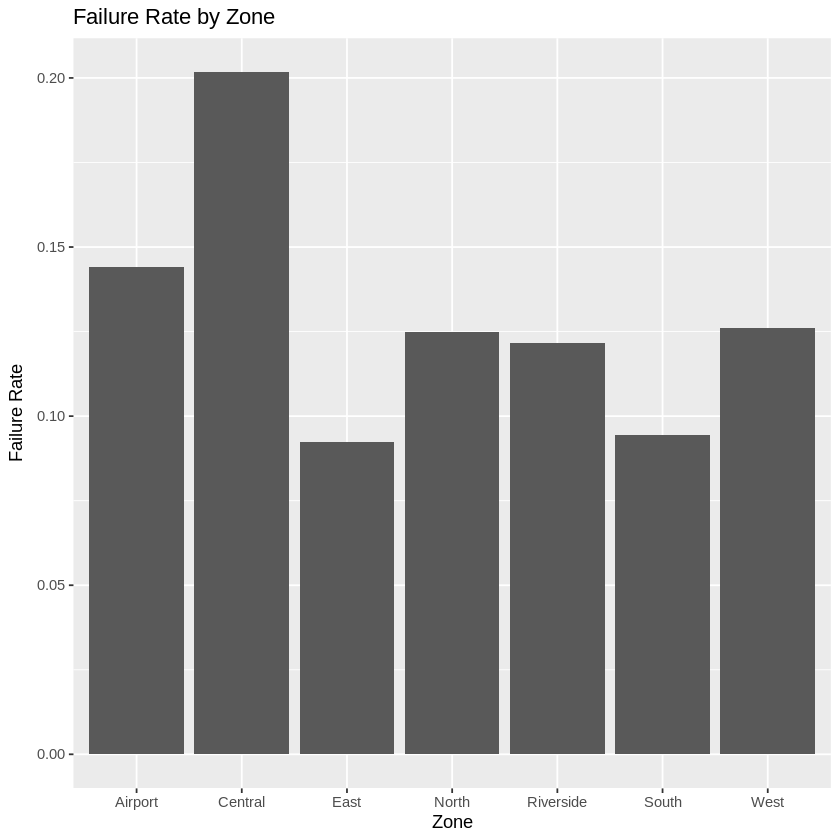

In [14]:
# Merging deliveries with hubs to get zone information
# stat="summary" with fun="mean" tells ggplot to calculate the average failure_flag per zone
deliveries_and_hubs <- merge(deliveries, hubs, by="hub_id")

ggplot(deliveries_and_hubs, aes(x = zone, y = failure_flag)) +
  geom_bar(stat = "summary", fun = "mean") +
  labs(title = "Failure Rate by Zone", x = "Zone", y = "Failure Rate")


### Result

Central zone has the highest failure rate, consistent with findings from both the Python notebook and the SQL queries. This confirms the pattern across three different tools.


## Box Plot: Delivery Duration by Service Type

Checking which service type takes the longest and which has the most inconsistent delivery times.


Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


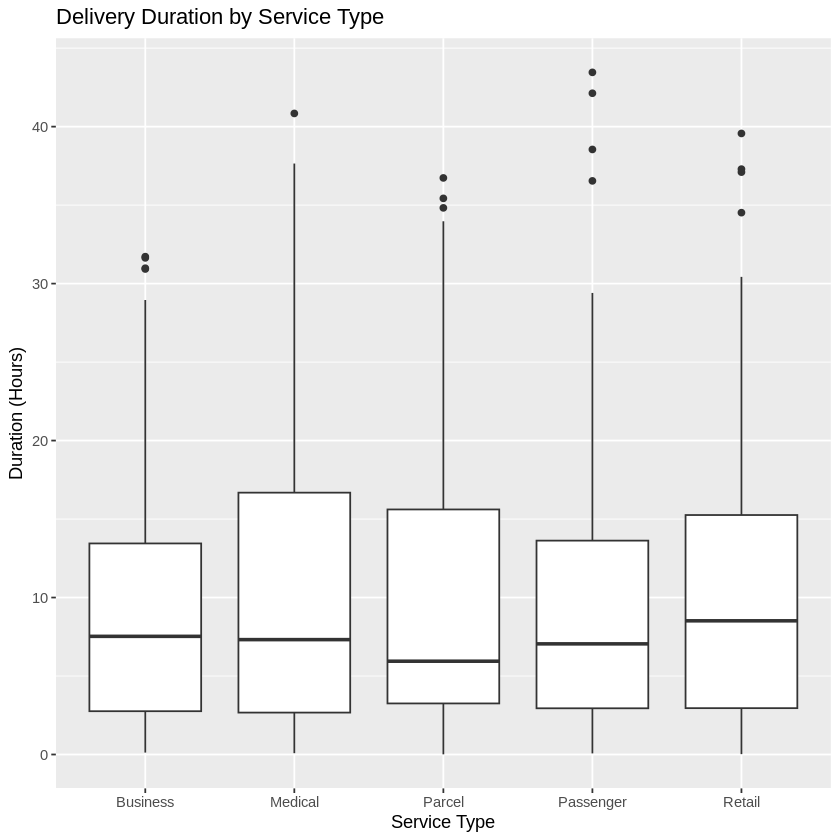

In [15]:
# Merging with orders to get service_type alongside duration_hours
merged_deliveries_orders <- merge(merged_deliveries, orders, by="order_id")

# Box plot - the middle line shows the median, the box shows the interquartile range
# Wide boxes mean more inconsistent delivery times
ggplot(merged_deliveries_orders, aes(x = service_type, y = duration_hours)) +
  geom_boxplot() +
  labs(title = "Delivery Duration by Service Type", x = "Service Type", y = "Duration (Hours)")


### Result
From the plot we can observe that Medical has most inconsistent delivery times which is concerning for North Star as Medical requires fast and consistent delivery times.
Also, Retail has the highest median delivery duration which backs our SQL (Query 2) finding that Retail has highest delays.

## Correlation Test

Testing whether manual override count and delivery duration are correlated.
If overrides cause delays, we would expect a positive correlation.


In [17]:
# Pearson correlation test between override count and duration
cor.test(merged_deliveries$manual_route_override_count, merged_deliveries$duration_hours)



	Pearson's product-moment correlation

data:  merged_deliveries$manual_route_override_count and merged_deliveries$duration_hours
t = -0.39427, df = 929, p-value = 0.6935
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.07712067  0.05135860
sample estimates:
        cor 
-0.01293442 


### Result
After running the test we find that the cor value is -0.013 which signifies that there is almost no relationship between the two. Also the p-value is 0.69 which is way above 0.05 signifying no relation

### Scatter Plot

Visualising the correlation to support the test result.


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`).”


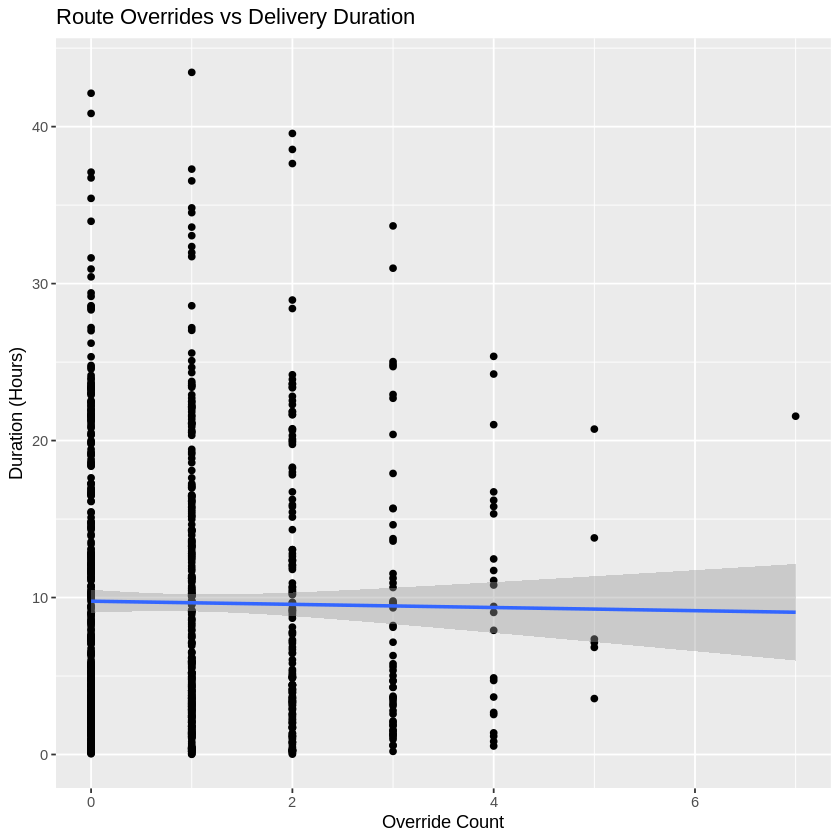

In [18]:
# geom_smooth(method="lm") adds a regression line to show the direction of the relationship
# A flat line means no relationship, a steep line means strong relationship
ggplot(merged_deliveries, aes(x = manual_route_override_count, y = duration_hours)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(title = "Route Overrides vs Delivery Duration",
       x = "Override Count",
       y = "Duration (Hours)")


### Result
From the plot we can see that most deliveries have 0-2 override counts. More importantly, the regression line a very minimal downward slope which backs our finding that there is no relation between overrides and delivery times.

## SUMMARY
1. **Linear Regression**: battery_health_pct was found to have a minimal impact on delivery failure rates.
2. **Multiple Regression**: Extending this, a multiple regression model was built. This confirmed that battery_health_pct and manual_route_override_count have negligible effects. However,proof_of_completion_missing was identified as a strong predictor of delivery failure. The R-squared value of 0.032 indicated that there are many other factors contributing to delivery failures that were not captured by this model.
3. **Zone vs. Failure Rate**: Failure rates were visualised across different zones, confirming Central as the worst performing zone.
4. **Service Type vs. Duration**: A boxplot revealed that the 'Medical' service type has the most inconsistent delivery times, which was noted as critical given its need for speed, and 'Retail' had the highest median delivery duration.
5. **Correlation between Overrides and Duration**: A correlation test and a scatter plot showed almost no relationship between manual_route_override_count and duration_hours (with a correlation coefficient of -0.013 and a high p-value of 0.69).

In a nutshell, this analysis highlighted that missing proof of completion is a significant factor in delivery failures, while battery health and manual route overrides have very little impact. Also, issues were identified with delivery consistency for Medical services and overall duration for Retail services.